In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

In [97]:
df = pd.read_csv('houses_to_rent_tratado.csv', sep=';')

df.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa,rent amount,property tax,fire insurance,total
0,1,240,3,3,4,NaN,1,1,0,8000,1000,121,9121
1,0,64,2,1,1,10.0,1,0,540,820,122,11,1493
2,1,443,5,5,4,3.0,1,1,4172,7000,1417,89,12680
3,1,73,2,2,1,12.0,1,0,700,1250,150,16,2116
4,1,19,1,1,0,NaN,0,0,0,1200,41,16,1257


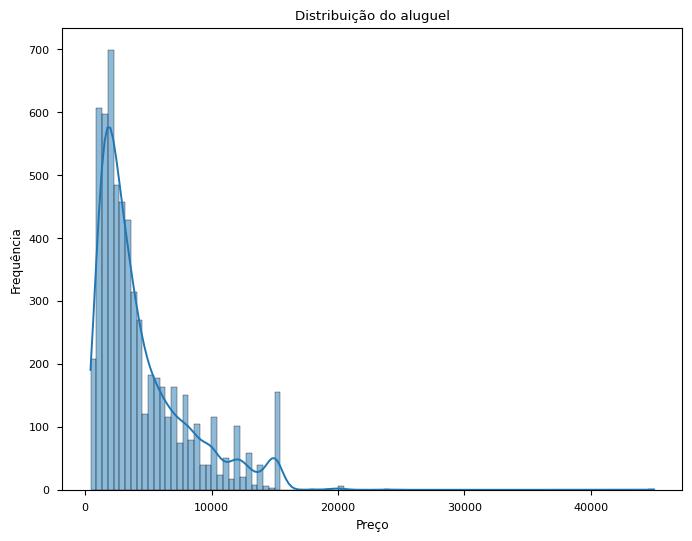

In [98]:
plt.style.use('seaborn-v0_8-paper')
plt.figure(figsize=(8, 6))
axe = plt.subplot()

sns.histplot(df['rent amount'], kde=True, ax=axe)
axe.set_title('Distribuição do aluguel')
axe.set_xlabel('Preço')
axe.set_ylabel('Frequência')

plt.savefig("histograma.pdf", format="pdf", bbox_inches='tight')
plt.show()

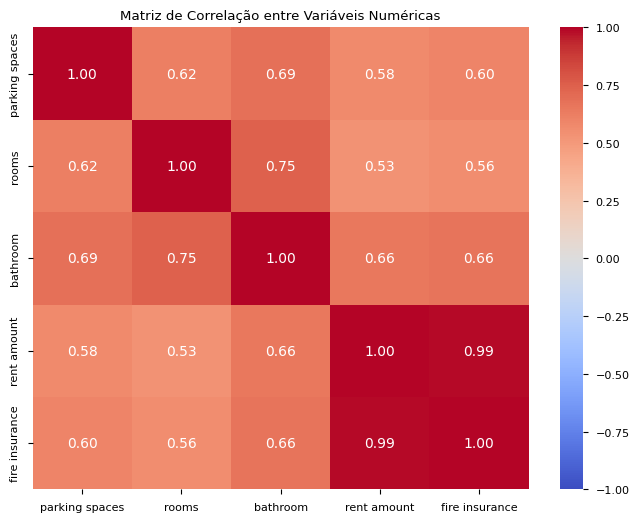

In [99]:
df_filtrado = df[['parking spaces','rooms', 'bathroom', 'rent amount', 'fire insurance']]

colunas_numericas = df_filtrado.select_dtypes(include=[np.number])
matriz_corr = colunas_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.savefig("heatmap.pdf", format="pdf", bbox_inches='tight')

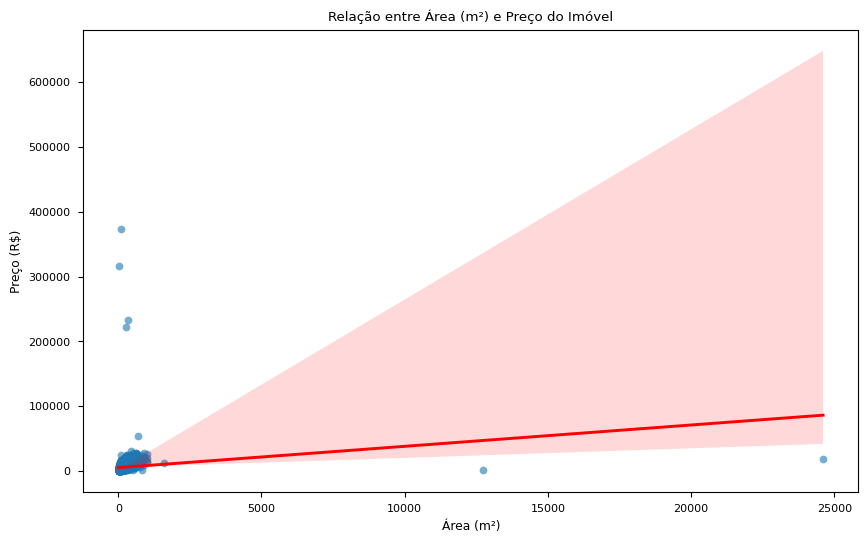

In [100]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='area',
    y='total',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('Relação entre Área (m²) e Preço do Imóvel')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (R$)')
plt.savefig("regplot.pdf", format="pdf", bbox_inches='tight')

In [101]:
# Filtro do IQR para ÁREA
Q1_area = df['area'].quantile(0.25)
Q3_area = df['area'].quantile(0.75)
IQR_area = Q3_area - Q1_area

limite_max_area = Q3_area + 3 * IQR_area
limite_min_area = Q1_area - 3 * IQR_area

# Filtro do IQR para TOTAL
Q1_total = df['total'].quantile(0.25)
Q3_total = df['total'].quantile(0.75)
IQR_total = Q3_total - Q1_total

limite_max_total = Q3_total + 3 * IQR_total
limite_min_total = Q1_total - 3 * IQR_total

df_limpo = df[
    (df['area'] >= limite_min_area) & (df['area'] <= limite_max_area) &
    (df['total'] >= limite_min_total) & (df['total'] <= limite_max_total)
]

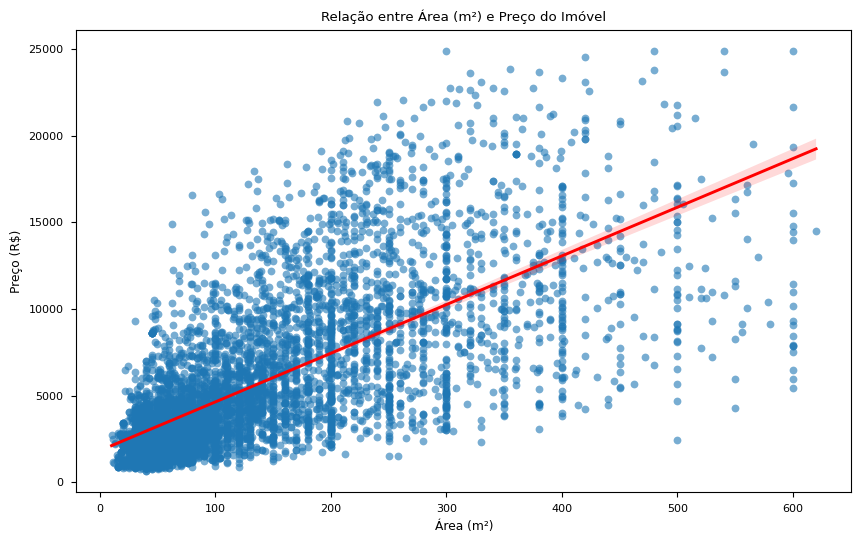

In [102]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_limpo,
    x='area',
    y='total',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('Relação entre Área (m²) e Preço do Imóvel')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (R$)')
plt.savefig("regplot_clean.pdf", format="pdf", bbox_inches='tight')

In [103]:
X = df_limpo[['area', 'rooms', 'bathroom', 'parking spaces', 'animal', 'furniture']]
y = df_limpo['total']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.DataFrame({
    'Atributo': X.columns,
    'Impacto no Preço (R$)': modelo.coef_
})

print(coeficientes)

         Atributo  Impacto no Preço (R$)
0            area              15.784251
1           rooms             -55.957725
2        bathroom            1067.737895
3  parking spaces             267.230683
4          animal            -223.998221
5       furniture            1776.518172


In [104]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Modelo": nome_modelo,
        "R²": f"{r2:.4f}",
        "MAE (R$)": f"R$ {mae:,.2f}",
        "RMSE (R$)": f"R$ {rmse:,.2f}"
    }

y_pred = modelo.predict(X_test)

resultados = calcular_metricas(y_test, y_pred, "Regressão Linear Básica")

df_resultados = pd.DataFrame([resultados])
print(df_resultados)

                    Modelo      R²     MAE (R$)    RMSE (R$)
0  Regressão Linear Básica  0.5830  R$ 2,039.86  R$ 2,926.68


In [105]:
X = df_limpo[['city', 'area', 'rooms', 'bathroom', 'parking spaces', 'animal', 'furniture']]
y = df_limpo['total']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.DataFrame({
    'Atributo': X.columns,
    'Impacto no Preço (R$)': modelo.coef_
})

print(coeficientes)

         Atributo  Impacto no Preço (R$)
0            city            1926.630677
1            area              15.596263
2           rooms             -24.775989
3        bathroom            1001.755319
4  parking spaces             290.744156
5          animal            -163.088273
6       furniture            1624.679135


In [107]:
y_pred = modelo.predict(X_test)

resultados = calcular_metricas(y_test, y_pred, "Regressão Linear Básica")

df_resultados = pd.DataFrame([resultados])
print(df_resultados)

                    Modelo      R²     MAE (R$)    RMSE (R$)
0  Regressão Linear Básica  0.6024  R$ 1,995.30  R$ 2,857.76


In [114]:
# teste do modelo

novo_imovel = pd.DataFrame([{
    'city': 1,
    'area': 80,
    'rooms': 2,
    'bathroom': 2,
    'parking spaces': 1,
    'animal': 1,
    'furniture': 1
}])

preco_previsto = modelo.predict(novo_imovel)[0]

print(f"Preço estimado para o imóvel: R$ {preco_previsto:,.2f}")

Preço estimado para o imóvel: R$ 5,732.37
